In [1]:
from ProjectFunctions import *

In [2]:
def mutual_info_fast(length, psi, a, b):
#length = length of spin chain
#psi = groundstate vector from respective model
#A = A spin
#B = B spin

    A = [a]
    B = [b]

#create a selection of "everything else" based on given A and B
    AB = [a,b]
    
#create reduced density matrices for each partition
    rhoA = Q.ptrace(psi,A)
    rhoB = Q.ptrace(psi,B)
    rhoAB = Q.ptrace(psi,AB)
    
#compute eigenvalues and entropy for A
    eigenvalsA = rhoA.eigenenergies()
    threshold1 = abs(eigenvalsA) < 10**(-8)
    eigenvalsA[threshold1] = 0
    #print(eigenvals)
    eigenvalscleanedA = [num for num in eigenvalsA if num != 0]
    #print(eigenvalscleaned)
    vnentropylistA = []
    for l in eigenvalscleanedA:
        vnentropylistA.append(-l*np.log(l))
        #print(vnentropylist)
        vnentropyA = sum(vnentropylistA)
    #print(vnentropyA)
    
#compute eigenvalues and entropy for B
    eigenvalsB = rhoB.eigenenergies()
    threshold1 = abs(eigenvalsB) < 10**(-8)
    eigenvalsB[threshold1] = 0
    #print(eigenvals)
    eigenvalscleanedB = [num for num in eigenvalsB if num != 0]
    #print(eigenvalscleaned)
    vnentropylistB = []
    for l in eigenvalscleanedB:
        vnentropylistB.append(-l*np.log(l))
        #print(vnentropylist)
        vnentropyB = sum(vnentropylistB)
    #print(vnentropyB)
    
#compute eigenvalues and entropy for C
    eigenvalsAB = rhoAB.eigenenergies()
    threshold1 = abs(eigenvalsAB) < 10**(-8)
    eigenvalsAB[threshold1] = 0
    #print(eigenvals)
    eigenvalscleanedAB = [num for num in eigenvalsAB if num != 0]
    #print(eigenvalscleaned)
    vnentropylistAB = []
    for l in eigenvalscleanedAB:
        vnentropylistAB.append(-l*np.log(l))
        #print(vnentropylist)
        vnentropyAB = sum(vnentropylistAB)
    #print(vnentropyC)
    
#compute the mutual information based on the previously computed entropy
    mutualinfo = vnentropyA + vnentropyB - vnentropyAB
#compute distance proxy from mutual information
    distance = (-np.log(mutualinfo/(2*np.log(2))))
    #distance = (-np.log(mutualinfo))/(2*np.log(2))
    return physdist, mutualinfo, distance#, vnentropyA, vnentropyB, vnentropyC

In [10]:
%%time
length = 8
hval = 0.1
jij = generate_jij(length, 14, 59)
Hint, Hintdiag = sg_interaction(length, jij)
Hfield = sg_field(length)
H = Hint + (hval * Hfield)
E, psi = H.groundstate()

CPU times: total: 46.9 ms
Wall time: 30.6 ms


In [11]:
%%time
distancelist = []
minfolist = []
for i in range(length):
    for j in range(i + 1, length):
        combinations, physdist, minfo, distance = mutual_info(length, psi, [i], [j])
        distancelist.append(distance)
        minfolist.append(minfo)

CPU times: total: 1.12 s
Wall time: 290 ms


In [12]:
%%time
distancelist = []
minfolist2 = []
for i in range(length):
    for j in range(i + 1, length):
        physdist, minfo, distance = mutual_info_fast(length, psi, i, j)
        distancelist.append(distance)
        minfolist2.append(minfo)

CPU times: total: 297 ms
Wall time: 282 ms


In [13]:
print(minfolist)

[3.712027584867883e-06, 4.789009786509979e-06, 0.250594300935407, 4.789009786287934e-06, 0.2505943009353817, 0.43488880710830535, 3.712027585311972e-06, 0.6897361001764073, 0.20764472841649106, 0.6897360678045521, 0.2089320610683838, 3.712027585534017e-06, 0.6878402854484833, 0.2081183855368467, 0.6919174758918378, 0.20811170425404946, 4.789009786287934e-06, 0.6897360678045521, 0.20811170425404457, 0.028998443636491178, 0.2505943009353857, 0.20893206106837914, 0.20811838553685136, 4.789009786509979e-06, 0.689736100176407, 0.25059430093540325, 0.20764472841649573, 3.712027585311972e-06]


In [14]:
print(minfolist2)

[3.712027585311972e-06, 4.789009786509979e-06, 0.2505943009354068, 4.789009786509979e-06, 0.25059430093538215, 0.4348888071083057, 3.7120275850899276e-06, 0.6897361001764071, 0.20764472841649106, 0.6897360678045517, 0.2089320610683838, 3.712027585311972e-06, 0.6878402854484833, 0.2081183855368467, 0.6919174758918379, 0.20811170425404946, 4.789009786509979e-06, 0.6897360678045523, 0.2081117042540448, 0.028998443636491178, 0.25059430093538637, 0.20893206106837892, 0.20811838553685136, 4.789009786509979e-06, 0.6897361001764069, 0.25059430093540325, 0.20764472841649573, 3.712027585534017e-06]


<function matplotlib.pyplot.show(close=None, block=None)>

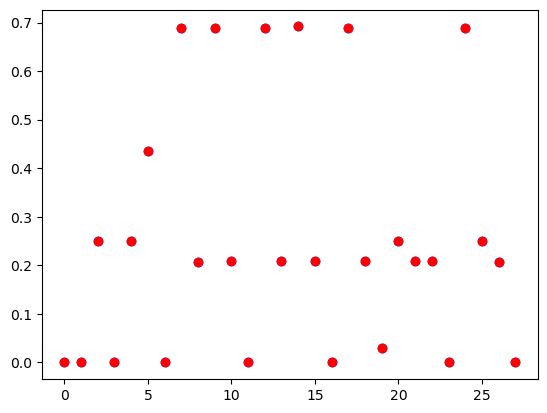

In [17]:
p1 = plt.plot(range(28),minfolist, 'ob')
p2 = plt.plot(range(28),minfolist2, 'or')
plt.show